In [ ]:
import tqdm
import numpy as np

def evaluate_model(model, df, vocab, device, num_samples=200):
    """Функция для оценки модели на выборке данных"""
    # Ограничиваем выборку для BERTScore, так как он ресурсозатратен
    eval_df = df.sample(min(num_samples, len(df)), random_state=42)

    references = eval_df['target_text'].tolist()
    hypotheses = []

    print(f"Генерация ответов для {len(eval_df)} примеров...")
    for sentence in tqdm.tqdm(eval_df['input_text']):
        # Используем функцию предсказания
        prediction = predict_response(sentence, model, vocab, device)
        hypotheses.append(prediction)

    # 1. Расчет ROUGE-L
    rouge_scores = [scorer.score(ref, hyp)['rougeL'].fmeasure for ref, hyp in zip(references, hypotheses)]
    avg_rouge = np.mean(rouge_scores)

    # 2. Расчет BERTScore
    P, R, F1 = bert_score_fn(hypotheses, references, lang="en", verbose=False)
    avg_bert_f1 = F1.mean().item()

    # 3. Расчет Distinct-2
    distinct_2 = calculate_distinct_n(hypotheses, n=2)

    print(f"\n--- Результаты оценки ---")
    print(f"ROUGE-L: {avg_rouge:.4f}")
    print(f"BERTScore F1: {avg_bert_f1:.4f}")
    print(f"Distinct-2: {distinct_2:.4f}")

    return avg_rouge, avg_bert_f1, distinct_2

# Запуск оценки
metrics = evaluate_model(model, val_df, vocab, DEVICE)

Генерация ответов для 200 примеров...


100%|██████████| 200/200 [00:04<00:00, 48.91it/s]


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Результаты оценки ---
ROUGE-L: 0.2161
BERTScore F1: 0.8461
Distinct-2: 0.0919


In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub
p = kagglehub.dataset_download("thoughtvector/customer-support-on-twitter")
p

Using Colab cache for faster access to the 'customer-support-on-twitter' dataset.


'/kaggle/input/customer-support-on-twitter'

Ccылка на датасет, а также инструкцию по скачке:
https://www.kaggle.com/datasets/thoughtvector/customer-support-on-twitter

In [ ]:
import pandas as pd
data = pd.read_csv(f'{p}/twcs/twcs.csv')
data.shape

(2811774, 7)

In [ ]:
data.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [ ]:
companies = data[data['inbound'] == False]['author_id'].value_counts()
companies.head(30)
# inbound это входящее/исходящее обрашение
# author_idпри неправде(флаг) это компания от которой исходящее обращение

,count
author_id,
AmazonHelp,169840
AppleSupport,106860
Uber_Support,56270
SpotifyCares,43265
Delta,42253
Tesco,38573
AmericanAir,36764
TMobileHelp,34317
comcastcares,33031


In [ ]:
message_company = data[data['inbound'] == False]
message_client = data[data['inbound'] == True]
message_client.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0
6,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,"9,6,10",NaN
8,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your co...,"11,13,14",15.0


In [ ]:
pairs = message_company.merge(message_client[['tweet_id', 'text']],
                              left_on='in_response_to_tweet_id', right_on='tweet_id',
                              suffixes=('_agent', '_client'))
pairs = pairs[['text_client', 'text_agent']]
pairs.columns = ['input_text', 'target_text']
pairs.head()

,input_text,target_text
0,@sprintcare I have sent several private messag...,@115712 I understand. I would like to assist y...
1,@sprintcare I did.,@115712 Please send us a Private Message so th...
2,@sprintcare is the worst customer service,@115712 Can you please send us a private messa...
3,@sprintcare You gonna magically change your co...,@115713 This is saddening to hear. Please shoo...
4,@sprintcare Since I signed up with you....Sinc...,@115713 We understand your concerns and we'd l...


In [ ]:
pairs.shape

(1261888, 2)

In [ ]:
import re
def f(a):
    a = re.sub(r'@\w+', '', a)
    a = re.sub(r'http\S+', '', a)
    a = a.strip()
    return a
pairs['input_text']  = pairs['input_text'].apply(f)
pairs['target_text'] = pairs['target_text'].apply(f)
pairs.head()

,input_text,target_text
0,I have sent several private messages and no on...,I understand. I would like to assist you. We w...
1,I did.,Please send us a Private Message so that we ca...
2,is the worst customer service,"Can you please send us a private message, so t..."
3,You gonna magically change your connectivity f...,This is saddening to hear. Please shoot us a D...
4,Since I signed up with you....Since day 1,We understand your concerns and we'd like for ...


In [ ]:
pairs = pairs[pairs['input_text'].str.len()  > 0]
pairs = pairs[pairs['target_text'].str.len() > 0]
pairs = pairs[pairs['input_text'].str.len()  >= 5]
pairs = pairs[pairs['target_text'].str.len() >= 5]
pairs = pairs.drop_duplicates()
pairs = pairs.reset_index(drop=True)
pairs.shape #пар после читски

(1241050, 2)

In [ ]:
# еда твиттер: длины текстов, топ компаний
import matplotlib.pyplot as plt
pairs['input_len']  = pairs['input_text'].str.len()
pairs['target_len'] = pairs['target_text'].str.len()
print(pairs[['input_len','target_len']].describe())

          input_len    target_len
count  1.241050e+06  1.241050e+06
mean   9.809943e+01  1.026217e+02
std    5.384637e+01  4.335186e+01
min    5.000000e+00  5.000000e+00
25%    5.800000e+01  7.500000e+01
50%    9.700000e+01  1.010000e+02
75%    1.260000e+02  1.230000e+02
max    2.960000e+02  2.990000e+02


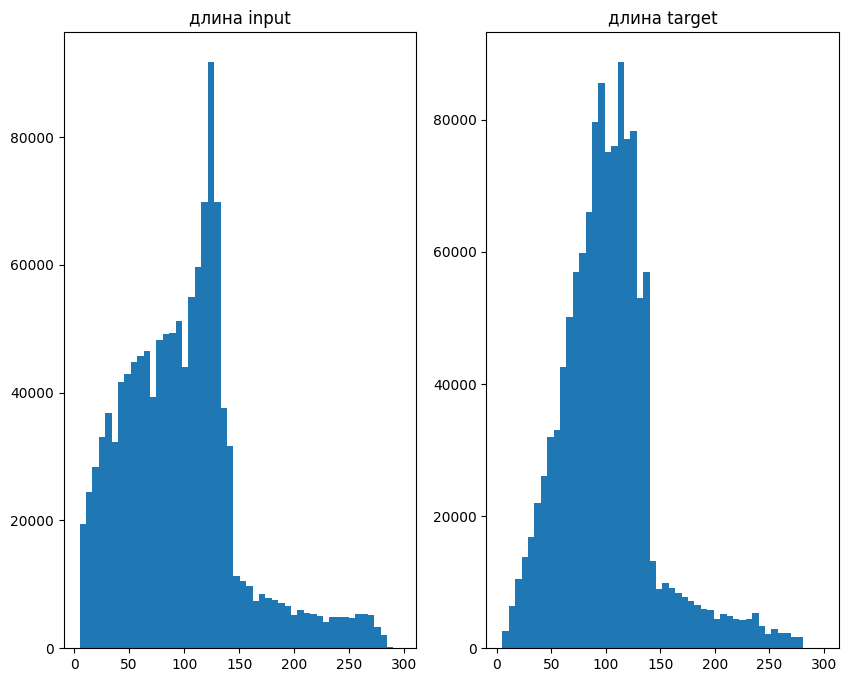

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,8))
axes[0].hist(pairs['input_len'].clip(upper=300), bins=50)
axes[0].set_title('длина input')
axes[1].hist(pairs['target_len'].clip(upper=300), bins=50)
axes[1].set_title('длина target')
plt.show()

In [ ]:
# оставляем тексты на английском, потому что Т5 наточена на английский
pairs = pairs[pairs['input_text'].apply(lambda x: sum(c.isascii() for c in x) / max(len(x),1) > 0.9)]
pairs = pairs[pairs['target_text'].apply(lambda x: sum(c.isascii() for c in x) / max(len(x),1) > 0.9)]
pairs = pairs.reset_index(drop=True)
pairs.shape

(1218867, 4)

In [ ]:
# убираем слишком длинные тексты, потому что там склеенные твиты при парсинге
pairs = pairs[pairs['input_text'].str.len()  <= 500]
pairs = pairs[pairs['target_text'].str.len() <= 500]
pairs = pairs.reset_index(drop=True)
pairs.shape

(1218867, 4)

In [ ]:
# убираем пары где ответ агента совпадает с сообщением клиента, это просто баг при. парсинге
pairs = pairs[pairs['input_text'] != pairs['target_text']]
pairs = pairs.reset_index(drop=True)
pairs.shape

(1218866, 4)

In [ ]:
# слова-маркеры намерения уйти или жалобы или недовольства, как раз то, что то относится к retention
retention_words = [
    'cancel', 'cancellation', 'terminate', 'termination',
    'leave', 'leaving', 'quit', 'unsubscribe',
    'too expensive', 'cheaper', 'competitor', 'switch',
    'disappointed', 'unhappy', 'dissatisfied', 'frustrated',
    'better offer', 'discount', 'refund', 'close account'
]

pattern = '|'.join(retention_words)
mask = pairs['input_text'].str.lower().str.contains(pattern, na=False)

print('retention строк:', mask.sum())
print('остальных:', (~mask).sum())

retention строк: 90607
остальных: 1128259


In [ ]:
# остальные строки исключаем - в них нет намерения уйти/жалобы/недовольства,
# это диалоги про трекинг заказов, технические вопросы и тд, не относится к retention
pairs = pairs[mask].drop(columns=['input_len','target_len']).reset_index(drop=True)
pairs['source'] = 'twitter'
pairs.shape

(90607, 3)

In [ ]:
from datasets import load_dataset

ds = load_dataset('bitext/Bitext-customer-support-llm-chatbot-training-dataset')
bitext = ds['train'].to_pandas()
bitext.shape

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

(26872, 5)

In [ ]:
bitext.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [ ]:
# распределение по интентам и длины
print(bitext['intent'].value_counts())

bitext['input_len']  = bitext['instruction'].str.len()
bitext['target_len'] = bitext['response'].str.len()
print(bitext[['input_len','target_len']].describe())

intent
contact_customer_service    1000
complaint                   1000
check_invoice               1000
switch_account              1000
edit_account                1000
contact_human_agent          999
check_payment_methods        999
delivery_period              999
newsletter_subscription      999
get_invoice                  999
payment_issue                999
registration_problems        999
cancel_order                 998
place_order                  998
track_refund                 998
change_order                 997
set_up_shipping_address      997
check_refund_policy          997
create_account               997
get_refund                   997
review                       997
delivery_options             995
delete_account               995
recover_password             995
track_order                  995
change_shipping_address      973
check_cancellation_fee       950
Name: count, dtype: int64
          input_len    target_len
count  26872.000000  26872.000000
mean    

In [ ]:
# интенты с сигналом оттока: отмена, жалоба, эскалация, ростальные (track_order, faq и тд) не про retention
retention_intents = ['cancel_order', 'complaint', 'contact_human_agent', 'get_refund', 'track_refund']
bitext = bitext[bitext['intent'].isin(retention_intents)].reset_index(drop=True)
bitext.shape

(4992, 7)

In [ ]:
bitext = bitext[['instruction', 'response']]
bitext.columns = ['input_text', 'target_text']
bitext = bitext.apply(lambda col: col.apply(f))
bitext.head()

,input_text,target_text
0,question about cancelling order {{Order Number}},I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},I can sense that you're seeking assistance wit...
3,I need to cancel purchase {{Order Number}},I understood that you need assistance with can...
4,"I cannot afford this order, cancel purchase {{...",I'm sensitive to the fact that you're facing f...


In [ ]:
# чистка длина, дубликаты, совпадение input/target
bitext = bitext[bitext['input_text'].str.len()  >= 5]
bitext = bitext[bitext['target_text'].str.len() >= 5]
bitext = bitext[bitext['input_text'].str.len()  <= 500]
bitext = bitext[bitext['target_text'].str.len() <= 500]
bitext = bitext[bitext['input_text'] != bitext['target_text']]
bitext = bitext.drop_duplicates()
bitext = bitext.reset_index(drop=True)
bitext['source'] = 'bitext'
bitext.shape

(1657, 3)

In [ ]:
# объединяем оба источника. битекст добавляет чистые возвратные кейсы с разметкой intent,
# твиттер добавляет объеи и разговорную стилистику
pairs = pd.concat([pairs, bitext], ignore_index=True)
pairs = pairs.drop_duplicates(subset=['input_text','target_text']).reset_index(drop=True)
print(pairs['source'].value_counts())
pairs.shape

source
twitter    90607
bitext      1657
Name: count, dtype: int64


(92264, 3)

In [ ]:
pairs[['input_text','target_text','source']].to_csv('retention_dialogs.csv', index=False)

In [ ]:
pairs

,input_text,target_text,source
0,Misrepresentation by host. Asked them to cance...,We are sorry to hear this. Please DM your emai...,twitter
1,"delivery I paid for today,didn’t arrive.why no...",Oh no! Please contact us via phone/chat here: ...,twitter
2,i’m pissed my shuffle and repeat button just ...,"Hey! What device, operating system, and Spotif...",twitter
3,Groove Music quits &amp; redirect to Spotify. ...,Hey there! That doesn't sound good. What's hap...,twitter
4,Hi ! My flight from MAN--LHR--BWI for Nov. 3 w...,caused. We're unable to offer a complimentary ...,twitter
...,...,...,...
92259,I have got to see my compensation current status,I comprehend your need to stay informed about ...,bitext
92260,check the current status of my compensation,I've grasped that you're eager to know the cur...,bitext
92261,I'm waiting for a reimbjrsement of {{Currency ...,"Firstly, I genuinely understand the importance...",bitext
92262,I don't know what to do to see my reimbursemen...,I've understood you're unsure about how to che...,bitext


In [ ]:
pairs['source'].unique()

array(['twitter', 'bitext'], dtype=object)

In [ ]:
import torch

def predict_response(sentence, model_obj, vocab_obj, device_obj, max_len=50):
    model_obj.eval()
    tokens = [2] + vocab_obj.encode(sentence) + [3]
    src_tensor = torch.LongTensor(tokens).unsqueeze(0).to(device_obj)

    with torch.no_grad():
        enc_outputs, (hidden, cell) = model_obj.encoder(model_obj.embedding(src_tensor))

    trg_indices = [2]
    for i in range(max_len):
        trg_tensor = torch.LongTensor([trg_indices[-1]]).to(device_obj)
        with torch.no_grad():
            embedded = model_obj.embedding(trg_tensor).unsqueeze(1)
            a = model_obj.attention(hidden[-1], enc_outputs).unsqueeze(1)
            weighted = torch.bmm(a, enc_outputs)
            rnn_input = torch.cat((embedded, weighted), dim=2)
            output, (hidden, cell) = model_obj.decoder(rnn_input, (hidden, cell))
            prediction = model_obj.out(torch.cat((output.squeeze(1), weighted.squeeze(1)), dim=1)).argmax(1)

        token = prediction.item()
        if token == 3:
            break
        trg_indices.append(token)

    return ' '.join([vocab_obj.itos[i] for i in trg_indices[1:]])

print("Чат готов! Напишите 'exit' для выхода.")
while True:
    user_text = input("Вы: ")
    if user_text.lower() in ['exit', 'stop', 'выход']:
        print("Диалог завершен.")
        break

    reply = predict_response(user_text, model, vocab, DEVICE)
    print(f"Бот: {reply}")

Чат готов! Напишите 'exit' для выхода.
Вы: hello
Бот: we can to to the you you can you dm us your full name, address and phone number and we can follow up.
Вы: fuck you
Бот: we want to to you with your account and we can to you you the <unk>
Вы: exit
Диалог завершен.


In [ ]:
### Установка библиотек для метрик
!pip install -q rouge_score bert_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.6 MB/s eta 0:00:00


In [ ]:
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn

# Инициализация скорера для ROUGE
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

def calculate_distinct_n(sentences, n=2):
    """Функция для расчета метрики Distinct-n (разнообразие ответов)"""
    total_ngrams = 0
    unique_ngrams = set()
    for sentence in sentences:
        tokens = sentence.split()
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        total_ngrams += len(ngrams)
        unique_ngrams.update(ngrams)
    return len(unique_ngrams) / total_ngrams if total_ngrams > 0 else 0.0

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import numpy as np

# Функция для разбиения текста на токены (слова) в нижнем регистре
def tokenize(text):
    return text.lower().split()

class Vocab:
    def __init__(self, texts, max_vocab_size=20000):
        counter = Counter() # Создаем счетчик для частоты слов
        for t in texts:
            counter.update(tokenize(t)) # Считаем каждое слово в текстах

        # Инициализируем словари для перевода индекса в слово и наоборот с базовыми токенами
        self.itos = {0: '<pad>', 1: '<unk>', 2: '<sos>', 3: '<eos>'}
        self.stoi = {v: k for k, v in self.itos.items()}

        # Добавляем наиболее частые слова в словари
        for word, _ in counter.most_common(max_vocab_size):
            if word not in self.stoi:
                idx = len(self.stoi)
                self.stoi[word] = idx
                self.itos[idx] = word

    def __len__(self):
        return len(self.stoi) # Возвращает общий размер словаря

    def encode(self, text):
        # Превращает текст в список числовых индексов
        return [self.stoi.get(w, 1) for w in tokenize(text)]

# Создаем словарь на основе всех входных и выходных текстов
vocab = Vocab(pairs['input_text'].tolist() + pairs['target_text'].tolist())

class ChatDataset(Dataset):
    def __init__(self, df, vocab):
        self.df = df # Датафрейм с парами фраз
        self.vocab = vocab # Объект словаря

    def __len__(self):
        return len(self.df) # Общее количество примеров в датасете

    def __getitem__(self, idx):
        # Кодируем входную фразу с метками начала (<sos>) и конца (<eos>)
        src = [2] + self.vocab.encode(self.df.iloc[idx]['input_text']) + [3]
        # Кодируем целевую фразу (ответ)
        trg = [2] + self.vocab.encode(self.df.iloc[idx]['target_text']) + [3]
        return torch.tensor(src), torch.tensor(trg)

def collate_fn(batch):
    src, trg = zip(*batch) # Распаковываем батч на входы и выходы
    # Выравниваем последовательности до одной длины в батче, заполняя нулями (<pad>)
    src = pad_sequence(src, padding_value=0, batch_first=True)
    trg = pad_sequence(trg, padding_value=0, batch_first=True)
    return src, trg

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        # Слой для вычисления весов внимания между текущим скрытым состоянием и выходами энкодера
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False) # Слой для получения оценки (score)

    def forward(self, hidden, encoder_outputs):
        seq_len = encoder_outputs.shape[1] # Длина входной последовательности
        # Дублируем скрытое состояние для каждого шага входа
        hidden = hidden.unsqueeze(1).repeat(1, seq_len, 1)
        # Вычисляем энергию (насколько важен каждый токен входа)
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        # Получаем итоговые оценки
        attention = self.v(energy).squeeze(2)
        # Применяем Softmax, чтобы сумма весов внимания была равна 1
        return torch.softmax(attention, dim=1)

class Seq2SeqAttention(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim) # Слой векторных представлений слов
        self.encoder = nn.LSTM(emb_dim, hidden_dim, batch_first=True) # Энкодер
        self.attention = Attention(hidden_dim) # Механизм внимания
        self.decoder = nn.LSTM(hidden_dim + emb_dim, hidden_dim, batch_first=True) # Декодер
        self.out = nn.Linear(hidden_dim * 2, vocab_size) # Выходной слой вероятностей слов

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0] # Размер батча
        trg_len = trg.shape[1] # Длина целевой фразы
        vocab_size = self.out.out_features # Объем словаря

        # Прогоняем вход через энкодер
        enc_outputs, (hidden, cell) = self.encoder(self.embedding(src))

        # Тензор для хранения предсказаний
        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(src.device)
        input = trg[:, 0] # Начальный токен для декодера

        for t in range(1, trg_len):
            embedded = self.embedding(input).unsqueeze(1) # Берем эмбеддинг текущего слова
            a = self.attention(hidden[-1], enc_outputs).unsqueeze(1) # Считаем веса внимания
            weighted = torch.bmm(a, enc_outputs) # Считаем контекстный вектор как взвешенную сумму

            # Объединяем эмбеддинг и контекст для входа в декодер
            rnn_input = torch.cat((embedded, weighted), dim=2)
            output, (hidden, cell) = self.decoder(rnn_input, (hidden, cell))

            # Предсказываем следующее слово
            prediction = self.out(torch.cat((output.squeeze(1), weighted.squeeze(1)), dim=1))
            outputs[:, t] = prediction # Сохраняем результат
            # Выбираем следующее слово: либо из правды (teacher forcing), либо свое предсказание
            input = trg[:, t] if np.random.random() < teacher_forcing_ratio else prediction.argmax(1)

        return outputs

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Выбор устройства
model = Seq2SeqAttention(len(vocab), 128, 256).to(DEVICE) # Создание и перенос модели на GPU
print(f'Model initialized on {DEVICE}')

Model initialized on cuda


In [ ]:
from sklearn.model_selection import train_test_split

# Разделяем данные: 90% на обучение и 10% на валидацию
train_df, val_df = train_test_split(pairs, test_size=0.1, random_state=42)

# Создаем объекты Dataset для обучения и теста
train_dataset = ChatDataset(train_df, vocab)
val_dataset = ChatDataset(val_df, vocab)

# Создаем загрузчики данных для подачи в модель частями (батчами)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

# Инициализируем оптимизатор Adam для обновления весов
optimizer = optim.Adam(model.parameters(), lr=0.001)
# Функция потерь - кросс-энтропия, игнорируем индекс 0 (<pad>)
criterion = nn.CrossEntropyLoss(ignore_index=0)

def train_epoch(model, loader, optimizer, criterion, clip=1):
    model.train() # Переводим модель в режим обучения
    epoch_loss = 0 # Переменная для накопления лосса за эпоху
    for i, (src, trg) in enumerate(loader):
        src, trg = src.to(DEVICE), trg.to(DEVICE) # Переносим данные на GPU

        optimizer.zero_grad() # Обнуляем градиенты с прошлого шага
        output = model(src, trg) # Прямой проход модели

        output_dim = output.shape[-1] # Размер словаря

        # Выпрямляем тензоры, чтобы передать их в функцию потерь
        # Убираем первый токен (<sos>), так как модель его не предсказывает
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg) # Считаем ошибку
        loss.backward() # Обратный проход - считаем градиенты

        # Ограничиваем норму градиента, чтобы предотвратить взрыв
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step() # Обновляем веса

        epoch_loss += loss.item() # Суммируем ошибку
        if i % 100 == 0:
            print(f'Step {i}, Loss: {loss.item():.4f}') # Печатаем прогресс каждые 100 шагов

    return epoch_loss / len(loader) # Возвращаем среднюю ошибку за эпоху

print("Starting baseline training...")
# Запуск обучения
train_epoch(model, train_loader, optimizer, criterion)

Starting baseline training...
Step 0, Loss: 9.9138
Step 100, Loss: 6.2002
Step 200, Loss: 5.8226
Step 300, Loss: 5.6911
Step 400, Loss: 5.5511
Step 500, Loss: 5.7726
Step 600, Loss: 5.1778
Step 700, Loss: 5.3547
Step 800, Loss: 5.1469
Step 900, Loss: 5.3957
Step 1000, Loss: 5.4545
Step 1100, Loss: 4.8344
Step 1200, Loss: 4.7659
Step 1300, Loss: 4.8771
Step 1400, Loss: 4.4735
Step 1500, Loss: 4.8842
Step 1600, Loss: 4.6024
Step 1700, Loss: 4.4116
Step 1800, Loss: 5.2427
Step 1900, Loss: 4.1175
Step 2000, Loss: 4.2578
Step 2100, Loss: 4.7929
Step 2200, Loss: 4.8022
Step 2300, Loss: 4.7366
Step 2400, Loss: 4.9470
Step 2500, Loss: 5.5527


5.042164653160668